# Type 2 Fuzzy Time Series — Milk Production — With Gaussian Noise
### Huarng & Yu (2005), *Physica A* 353, 445–462
Pure NumPy implementation. Metrics: RMSE, MSE, NMSE, sMAPE.

**Noise levels:** 0.5 %, 5 %, 10 %  
**Formula:** σ = λ · std(original\_data), noise ~ N(0, σ)  
**Protocol:** 30 runs per noise level, reported as mean ± std


In [8]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
import os
print(f"Process ID (PID): {os.getpid()}")

Process ID (PID): 2607


In [9]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
import time as _timer_module
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")

Notebook execution started at: 2026-05-22 21:45:54


In [10]:
# ============================================================
# ALL IMPORTS  (pure NumPy — no sklearn / pandas-fuzzy / statsmodels)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import csv, math

np.set_printoptions(precision=6, suppress=True)
print(f"NumPy version: {np.__version__}")

# ── Metric helpers ──────────────────────────────────────────
def calc_rmse(actual, predicted):
    """Root Mean Squared Error."""
    return float(np.sqrt(np.mean((np.asarray(actual) - np.asarray(predicted))**2)))

def calc_mse(actual, predicted):
    """Mean Squared Error."""
    return float(np.mean((np.asarray(actual) - np.asarray(predicted))**2))

def calc_nmse(actual, predicted):
    """Normalised MSE  = MSE / ||pred - mean(actual)||^2."""
    a, p = np.asarray(actual, float), np.asarray(predicted, float)
    mse = np.mean((a - p)**2)
    denom = np.linalg.norm(p - np.mean(a), 2)**2
    return float(mse / denom) if denom != 0 else float('inf')

def calc_smape(actual, predicted):
    """Symmetric MAPE (%)."""
    a, p = np.asarray(actual, float), np.asarray(predicted, float)
    return float(100.0/len(a) * np.sum(2*np.abs(p-a)/(np.abs(a)+np.abs(p)+1e-8)))

NumPy version: 1.26.4


In [11]:
# ============================================================
# 1. Load Time Series Data — Milk Production
# ============================================================
CSV_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")),
                        r"../../content/monthly-milk-production-pounds-p.csv")

dates, values = [], []
with open(CSV_PATH, "r") as f:
    reader = csv.reader(f)
    header = next(reader)
    for row in reader:
        if len(row) < 2: continue
        dates.append(row[0].strip().strip('"'))
        values.append(float(row[1].strip().strip('"')))

data = np.array(values, dtype=np.float64)
print(f"Dataset : Milk Production")
print(f"Shape   : {data.shape}")
print(f"First 5 : {list(zip(dates[:5], data[:5]))}")

Dataset : Milk Production
Shape   : (168,)
First 5 : [('1962-01', 589.0), ('1962-02', 561.0), ('1962-03', 640.0), ('1962-04', 656.0), ('1962-05', 727.0)]


In [12]:
# ============================================================
# 2. Gaussian Noise Setup
#    Save original data, compute std, define noise levels.
#    sigma = lambda * std(original_data)
#    noise = N(0, sigma),  data = original + noise
#    30-run experiment protocol per noise level.
# ============================================================
original_data = np.copy(data)
s_x = np.std(original_data)
noise_levels = [0.005, 0.05, 0.1]   # 0.5 %, 5 %, 10 %
N_RUNS = 30

print(f"Original data std (s_x): {s_x:.6f}")
print(f"Noise levels (lambda):   {noise_levels}")
print(f"Corresponding sigma:     {[round(lam * s_x, 6) for lam in noise_levels]}")
print(f"Runs per noise level:    {N_RUNS}")

Original data std (s_x): 101.899890
Noise levels (lambda):   [0.005, 0.05, 0.1]
Corresponding sigma:     [0.509499, 5.094994, 10.189989]
Runs per noise level:    30



EVALUATING NOISE LEVEL: 0.5% (lambda=0.005, sigma=0.509499)
Running 30 experiments...

  ... completed run 10/30
  ... completed run 20/30
  ... completed run 30/30

  Results for Noise Level 0.5% (30 runs):
  Model                                        RMSE                      sMAPE
  ----------------------------------------------------------------------------
  Type 1 (Chen)           51.342320 ± 3.416247      4.552544 ± 0.315335  
  Intersection (∧_m)      51.192720 ± 3.373297      4.817175 ± 0.265562  
  Union (∨_m)             52.450159 ± 3.677545      4.992080 ± 0.322857  
  Type 2 (average)        50.066192 ± 3.545390      4.666152 ± 0.279260  


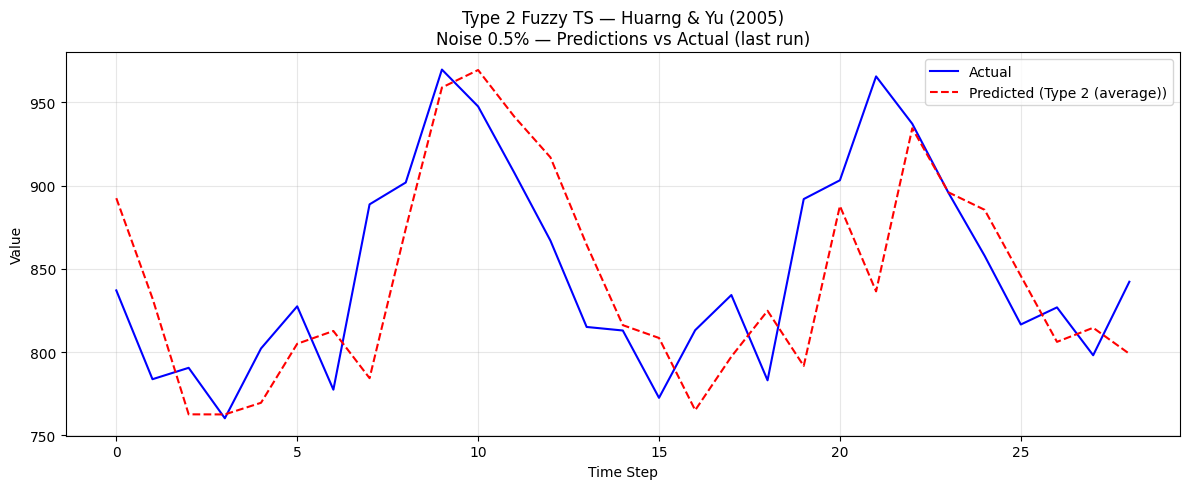

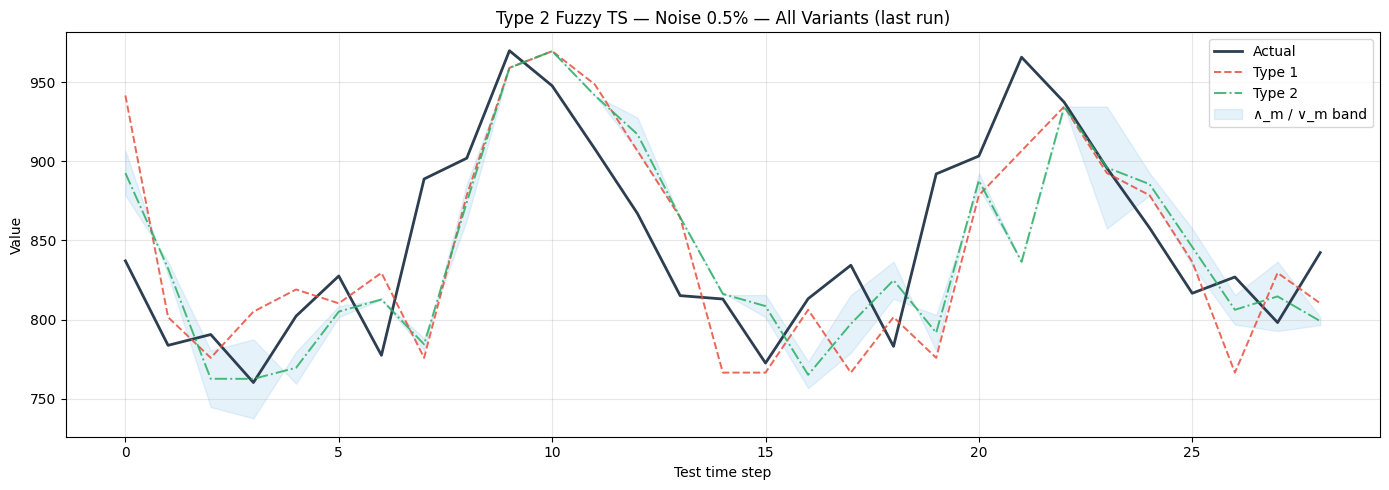


EVALUATING NOISE LEVEL: 5.0% (lambda=0.05, sigma=5.094994)
Running 30 experiments...

  ... completed run 10/30
  ... completed run 20/30
  ... completed run 30/30

  Results for Noise Level 5.0% (30 runs):
  Model                                        RMSE                      sMAPE
  ----------------------------------------------------------------------------
  Type 1 (Chen)           48.354165 ± 4.564916      4.387332 ± 0.462473  
  Intersection (∧_m)      50.089930 ± 3.523624      4.895715 ± 0.332837  
  Union (∨_m)             51.118075 ± 4.000258      4.819052 ± 0.460408  
  Type 2 (average)        48.916063 ± 3.326547      4.680007 ± 0.323564  


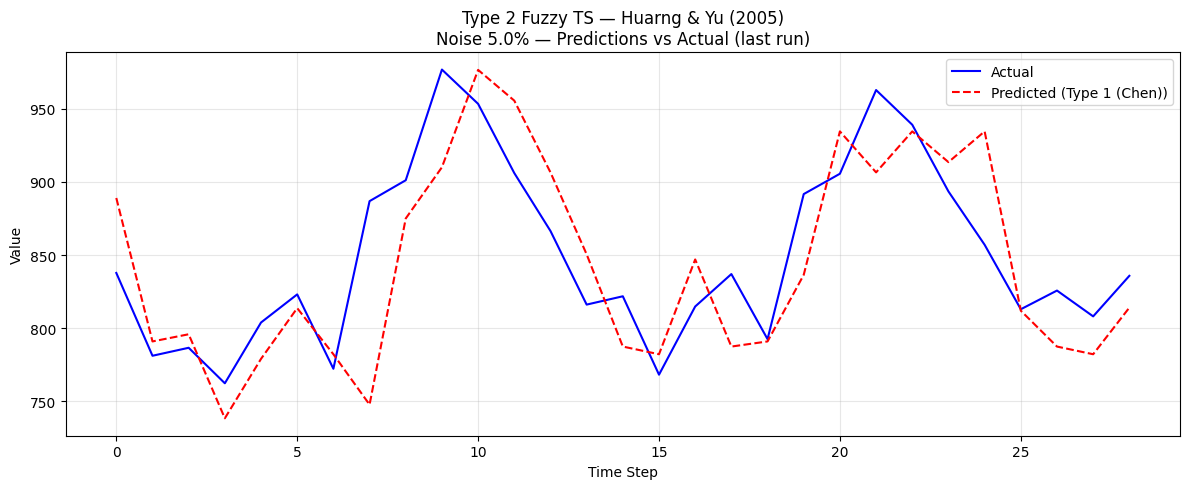

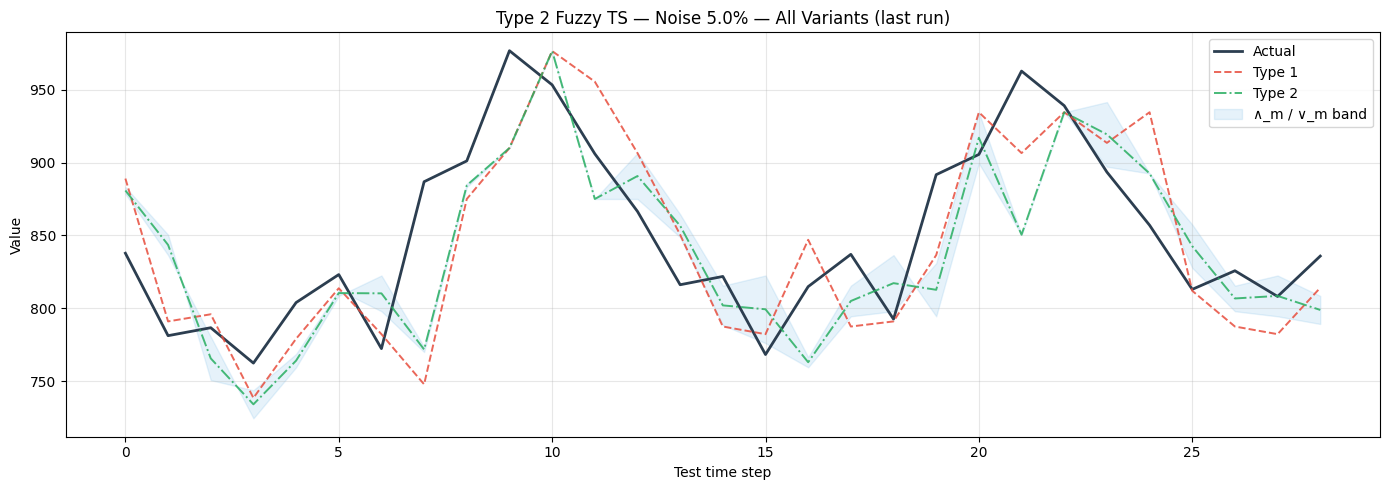


EVALUATING NOISE LEVEL: 10.0% (lambda=0.1, sigma=10.189989)
Running 30 experiments...

  ... completed run 10/30
  ... completed run 20/30
  ... completed run 30/30

  Results for Noise Level 10.0% (30 runs):
  Model                                        RMSE                      sMAPE
  ----------------------------------------------------------------------------
  Type 1 (Chen)           51.288956 ± 6.235712      4.779653 ± 0.580613  
  Intersection (∧_m)      52.650740 ± 4.908377      5.107531 ± 0.463436  
  Union (∨_m)             53.459823 ± 5.058728      5.046830 ± 0.564530  
  Type 2 (average)        51.481355 ± 4.783920      4.922683 ± 0.482258  


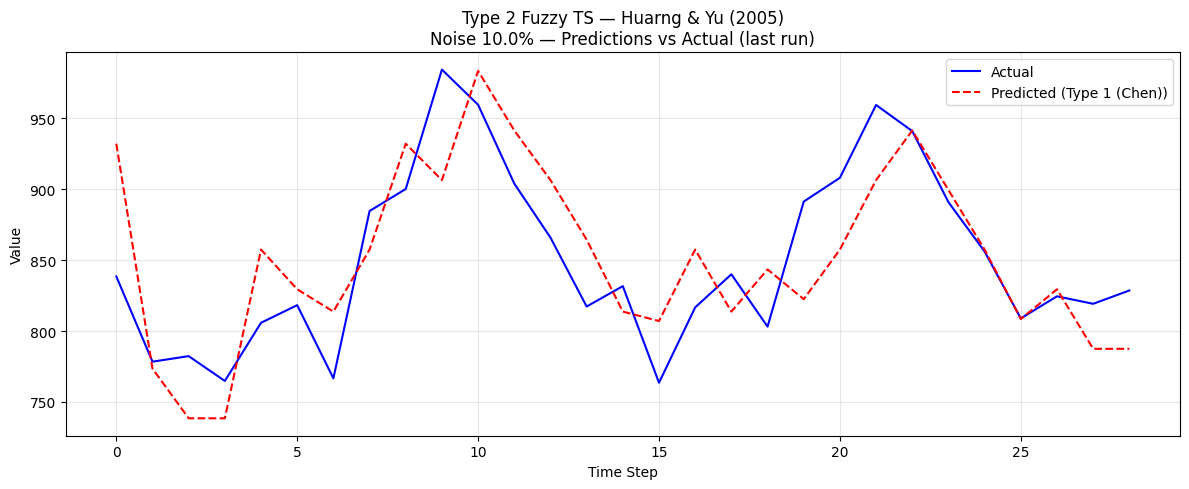

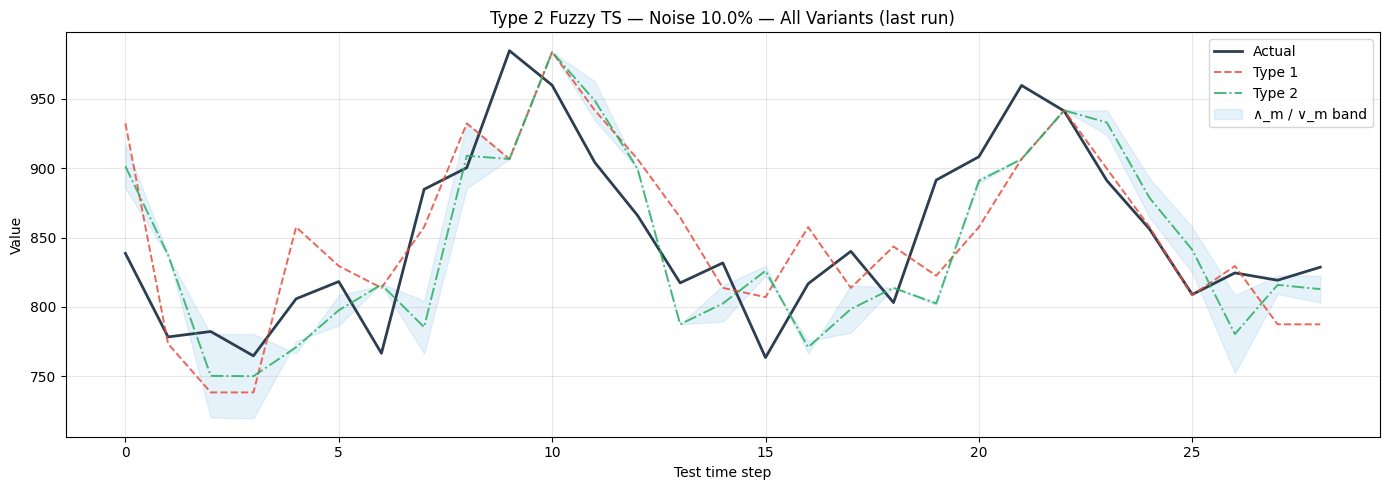

In [13]:
# ============================================================
# 3-10. Full Pipeline — Looped Over Noise Levels (30 runs each)
# ============================================================
variant_names = ["Type 1 (Chen)", "Intersection (∧_m)", "Union (∨_m)", "Type 2 (average)"]
all_noise_results = {}   # collect results for consolidated summary

for lam in noise_levels:
    sigma = lam * s_x
    noise_label = f"{lam*100:.1f}%"
    print("\n" + "=" * 80)
    print(f"EVALUATING NOISE LEVEL: {noise_label} (lambda={lam}, sigma={sigma:.6f})")
    print(f"Running {N_RUNS} experiments...")
    print("=" * 80 + "\n")

    # ── Storage for per-run metrics ─────────────────────────
    run_metrics = {vn: {"rmse": [], "mse": [], "nmse": [], "smape": []}
                   for vn in variant_names}

    for run_idx in range(N_RUNS):
        # ── Apply Gaussian noise with unique seed ───────────
        seed = run_idx + 1
        np.random.seed(seed)
        noise = np.random.normal(0, sigma, size=original_data.shape)
        data = original_data + noise

        # ── Train / Test Split (83 % / 17 %) ────────────────
        TRAIN_RATIO = 0.83
        split_idx = int(len(data) * TRAIN_RATIO)
        train_data = data[:split_idx]
        test_data  = data[split_idx:]

        # ── Universe of Discourse & Interval Partitioning ────
        def compute_universe(train, target_K=57):
            D_min, D_max = float(np.min(train)), float(np.max(train))
            raw_w = (D_max - D_min) / target_K
            if raw_w == 0: raw_w = 1.0
            mag = 10 ** math.floor(math.log10(raw_w))
            w = round(raw_w / mag) * mag
            if w == 0: w = mag
            U_lo = math.floor(D_min / w) * w - w
            U_hi = math.ceil(D_max / w)  * w + w
            K = int(round((U_hi - U_lo) / w))
            return D_min, D_max, U_lo, U_hi, w, K

        D_min, D_max, U_lo, U_hi, w, K = compute_universe(train_data)
        midpoints = np.array([U_lo + (k + 0.5) * w for k in range(K)])

        # ── Fuzzification ────────────────────────────────────
        def fuzzify(x, midpoints):
            return int(np.argmin(np.abs(midpoints - x)))

        def fuzzify_series(series, midpoints):
            return np.array([fuzzify(x, midpoints) for x in series])

        # ── FLR & FLRG Construction ──────────────────────────
        def build_flr(fuzzified):
            return [(fuzzified[t-1], fuzzified[t]) for t in range(1, len(fuzzified))]

        def build_flrg(flrs, K):
            flrg = {k: set() for k in range(K)}
            for lhs, rhs in flrs:
                flrg[lhs].add(rhs)
            return flrg

        fuzzified_train = fuzzify_series(train_data, midpoints)
        flrs = build_flr(fuzzified_train)
        flrg = build_flrg(flrs, K)

        # ── Type 2 Observations ──────────────────────────────
        def rolling_std(series, window=5):
            stds = np.empty(len(series))
            for t in range(len(series)):
                stds[t] = np.std(series[max(0,t-window+1):t+1], ddof=0)
            return stds

        full_std  = rolling_std(data, window=5)
        obs_high  = data + full_std
        obs_low   = data - full_std
        fuzz_all  = fuzzify_series(data, midpoints)
        fuzz_high = fuzzify_series(obs_high, midpoints)
        fuzz_low  = fuzzify_series(obs_low, midpoints)

        # ── Operators ────────────────────────────────────────
        def union_m(lhs_indices, flrg, type1_lhs):
            result = set()
            for idx in lhs_indices:
                result |= flrg.get(idx, set())
            if not result:
                result = flrg.get(type1_lhs, set())
            if not result:
                result = {type1_lhs}
            return result

        def intersection_m(lhs_indices, flrg, type1_lhs):
            non_empty = [flrg.get(idx, set()) for idx in lhs_indices]
            non_empty = [s for s in non_empty if s]
            if not non_empty:
                return {type1_lhs}
            result = non_empty[0]
            for s in non_empty[1:]:
                result = result & s
            if not result:
                result = {type1_lhs}
            return result

        # ── Forecasting ──────────────────────────────────────
        def defuzzify(fset, midpoints):
            if not fset: return np.nan
            return float(np.mean([midpoints[j] for j in sorted(fset)]))

        actuals, pred_t1, pred_int, pred_uni, pred_t2 = [], [], [], [], []

        for t in range(split_idx, len(data)):
            actuals.append(data[t])
            l1  = int(fuzz_all[t-1])
            lhi = int(fuzz_high[t-1])
            llo = int(fuzz_low[t-1])

            rhs1 = flrg.get(l1, set()) or {l1}
            f1 = defuzzify(rhs1, midpoints)

            i_s = intersection_m([l1, lhi, llo], flrg, l1)
            fi = defuzzify(i_s, midpoints)

            u_s = union_m([l1, lhi, llo], flrg, l1)
            fu = defuzzify(u_s, midpoints)

            f2 = (fi + fu) / 2.0

            pred_t1.append(f1); pred_int.append(fi)
            pred_uni.append(fu); pred_t2.append(f2)

        actuals  = np.array(actuals)
        pred_t1  = np.array(pred_t1)
        pred_int = np.array(pred_int)
        pred_uni = np.array(pred_uni)
        pred_t2  = np.array(pred_t2)

        # ── Collect metrics for this run ─────────────────────
        preds_map = dict(zip(variant_names, [pred_t1, pred_int, pred_uni, pred_t2]))
        for vn in variant_names:
            p = preds_map[vn]
            run_metrics[vn]["rmse"].append(calc_rmse(actuals, p))
            run_metrics[vn]["mse"].append(calc_mse(actuals, p))
            run_metrics[vn]["nmse"].append(calc_nmse(actuals, p))
            run_metrics[vn]["smape"].append(calc_smape(actuals, p))

        if (run_idx + 1) % 10 == 0:
            print(f"  ... completed run {run_idx + 1}/{N_RUNS}")

    # ── Per-noise-level results (mean ± std) ────────────────
    print(f"\n  Results for Noise Level {noise_label} ({N_RUNS} runs):")
    print("  " + "=" * 76)
    print(f"  {'Model':<22s} {'RMSE':>26s} {'sMAPE':>26s}")
    print("  " + "-" * 76)
    for vn in variant_names:
        rm = np.mean(run_metrics[vn]["rmse"])
        rs = np.std(run_metrics[vn]["rmse"])
        sm = np.mean(run_metrics[vn]["smape"])
        ss = np.std(run_metrics[vn]["smape"])
        print(f"  {vn:<22s} {rm:10.6f} ± {rs:<10.6f}  {sm:10.6f} ± {ss:<10.6f}")
    print("  " + "=" * 76)

    # ── Store for consolidated summary ──────────────────────
    summary = {}
    for vn in variant_names:
        summary[vn] = {}
        for mk in ["rmse", "mse", "nmse", "smape"]:
            vals = np.array(run_metrics[vn][mk])
            summary[vn][mk] = {"mean": float(np.mean(vals)),
                               "std":  float(np.std(vals))}
    all_noise_results[noise_label] = summary

    # ── Plot (last run) ─────────────────────────────────────
    best_vn = min(variant_names, key=lambda v: summary[v]["rmse"]["mean"])
    best_preds = preds_map[best_vn]

    plt.figure(figsize=(12, 5))
    plt.plot(actuals, label='Actual', color='blue', linewidth=1.5)
    plt.plot(best_preds, label=f'Predicted ({best_vn})', color='red',
             linewidth=1.5, linestyle='--')
    plt.title(f'Type 2 Fuzzy TS — Huarng & Yu (2005)\n'
              f'Noise {noise_label} — Predictions vs Actual (last run)')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 5))
    t_axis = np.arange(len(actuals))
    ax.plot(t_axis, actuals,  lw=2.0, label="Actual",  color="#2c3e50")
    ax.plot(t_axis, pred_t1,  lw=1.4, label="Type 1",  color="#e74c3c", ls="--", alpha=0.85)
    ax.plot(t_axis, pred_t2,  lw=1.4, label="Type 2",  color="#27ae60", ls="-.", alpha=0.85)
    ax.fill_between(t_axis, pred_int, pred_uni,
                    alpha=0.12, color="#3498db", label="∧_m / ∨_m band")
    ax.set_xlabel("Test time step"); ax.set_ylabel("Value")
    ax.set_title(f"Type 2 Fuzzy TS — Noise {noise_label} — All Variants (last run)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [14]:
# ============================================================
# CONSOLIDATED SUMMARY — All Noise Levels (mean ± std)
# ============================================================
print("\n")
print("#" * 96)
print("#" + " CONSOLIDATED RESULTS — ALL NOISE LEVELS (mean ± std) ".center(94) + "#")
print("#" * 96)

variant_names_s = ["Type 1 (Chen)", "Intersection (∧_m)", "Union (∨_m)", "Type 2 (average)"]
metric_labels = ["RMSE", "MSE", "NMSE", "sMAPE"]
metric_keys   = ["rmse", "mse", "nmse", "smape"]

for ml, mk in zip(metric_labels, metric_keys):
    print(f"\n{'─'*96}")
    print(f"  {ml}")
    print(f"{'─'*96}")
    # Header
    header = f"  {'Variant':<22s}"
    for nl in all_noise_results:
        header += f" {'Noise ' + nl:>24s}"
    print(header)
    print(f"  {'─'*22}" + f" {'─'*24}" * len(all_noise_results))
    # Rows
    for vn in variant_names_s:
        row = f"  {vn:<22s}"
        for nl, summary in all_noise_results.items():
            m = summary[vn][mk]["mean"]
            s = summary[vn][mk]["std"]
            if mk == "nmse":
                row += f" {m:10.8f}±{s:<10.8f}"
            else:
                row += f" {m:10.6f}±{s:<10.6f}"
        print(row)

# ── Best variant per noise level ────────────────────────────
print(f"\n{'─'*96}")
print(f"  Best Variant per Noise Level (by lowest mean RMSE)")
print(f"{'─'*96}")
for nl, summary in all_noise_results.items():
    best_vn = min(variant_names_s, key=lambda v: summary[v]["rmse"]["mean"])
    rm = summary[best_vn]["rmse"]
    mm = summary[best_vn]["mse"]
    nm = summary[best_vn]["nmse"]
    sm = summary[best_vn]["smape"]
    print(f"  Noise {nl:>5s}:  {best_vn:<22s}")
    print(f"           RMSE  = {rm['mean']:.6f} ± {rm['std']:.6f}")
    print(f"           MSE   = {mm['mean']:.6f} ± {mm['std']:.6f}")
    print(f"           NMSE  = {nm['mean']:.10f} ± {nm['std']:.10f}")
    print(f"           sMAPE = {sm['mean']:.6f} ± {sm['std']:.6f}")

print(f"\n{'#'*96}")



################################################################################################
#                     CONSOLIDATED RESULTS — ALL NOISE LEVELS (mean ± std)                     #
################################################################################################

────────────────────────────────────────────────────────────────────────────────────────────────
  RMSE
────────────────────────────────────────────────────────────────────────────────────────────────
  Variant                              Noise 0.5%               Noise 5.0%              Noise 10.0%
  ────────────────────── ──────────────────────── ──────────────────────── ────────────────────────
  Type 1 (Chen)           51.342320±3.416247    48.354165±4.564916    51.288956±6.235712  
  Intersection (∧_m)      51.192720±3.373297    50.089930±3.523624    52.650740±4.908377  
  Union (∨_m)             52.450159±3.677545    51.118075±4.000258    53.459823±5.058728  
  Type 2 (average)        50.066

In [15]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
import time as _timer_module
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")


Total notebook execution time: 0h 0m 1.07s
Total seconds: 1.07
